# Rocket Elevators — Análisis Exploratorio de Datos

---

## Objetivo

Realizar un análisis inicial del dataset de licencias de ascensores de Ontario
para confirmar que los datos son **utilizables** para el dashboard de operaciones.

---

## Descripción del Dataset

| Propiedad | Valor |
|-----------|-------|
| Archivo | `data/elevator_licenses.csv` |
| Registros aproximados | ~45 383 ascensores |
| Origen | Registro de licencias del Ministerio de Trabajo de Ontario |
| Formato de fechas | `DD-Mon-YY` (ejemplo: `28-Apr-17`) |

## Columnas Clave

| Columna | Descripción |
|---------|-------------|
| `ElevatingDevicesNumber` | Identificador único del ascensor |
| `LocationoftheElevatingDevice` | Dirección completa (incluye ciudad) |
| `ElevatingDevicesLicenseNumber` | Número de licencia |
| `LICENSESTATUS` | Estado: `ACTIVE`, `BY REQUEST`, `CANCELLED_NOT_RENEWED` |
| `LICENSEEXPIRYDATE` | Fecha de vencimiento de la licencia |
| `LICENSEHOLDER` | Titular de la licencia |

---

**Especificación:** `docs/data_analysis_spec.md`

## 1. Importación de Librerías y Constantes

Se importan todas las librerías necesarias y se definen las constantes globales.
Las constantes se escriben en **MAYÚSCULAS** para distinguirlas de las variables.

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Rutas ─────────────────────────────────────────────────────────────────────
DATA_FILE  = Path('../data/elevator_licenses.csv')
CHARTS_DIR = Path('../docs/charts')
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Formato de fecha del CSV ──────────────────────────────────────────────────
DATE_FORMAT = '%d-%b-%y'

# ── Fecha de referencia para cálculos de vencimiento ─────────────────────────
TODAY = pd.Timestamp.today().normalize()

# ── Valores de estado de licencia ────────────────────────────────────────────
STATUS_ACTIVE    = 'ACTIVE'
STATUS_BY_REQ    = 'BY REQUEST'
STATUS_CANCELLED = 'CANCELLED_NOT_RENEWED'

# ── Paleta de colores del dashboard ──────────────────────────────────────────
COLOR_GREEN  = '#10b981'
COLOR_YELLOW = '#f59e0b'
COLOR_RED    = '#ef4444'
COLOR_BLUE   = '#2563eb'
COLOR_GRAY   = '#6b7280'

# ── Estilo global de gráficas ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        130,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
})

print('Librerías cargadas correctamente.')
print(f'Fecha de análisis  : {TODAY.date()}')
print(f'Directorio gráficas: {CHARTS_DIR.resolve()}')

Librerías cargadas correctamente.
Fecha de análisis  : 2026-06-01
Directorio gráficas: C:\rocket-elevators\docs\charts


## 2. Carga del CSV y Exploración Básica

Se carga el archivo con todas las columnas como texto (`dtype=str`) para evitar
conversiones automáticas incorrectas en IDs numéricos.
Luego se parsean las fechas y se extrae la ciudad mediante expresión regular.

> **Nota:** El valor `"data redacted"` en campos de cuenta es válido y no debe tratarse como error.

In [2]:
# Cargar CSV — todas las columnas como texto para preservar IDs
df = pd.read_csv(DATA_FILE, dtype=str, low_memory=False)

# Parsear fechas (formato DD-Mon-YY, ejemplo: 28-Apr-17)
df['LICENSEEXPIRYDATE'] = pd.to_datetime(
    df['LICENSEEXPIRYDATE'], format=DATE_FORMAT, errors='coerce'
)

# Normalizar espacios en estado de licencia
df['LICENSESTATUS'] = df['LICENSESTATUS'].str.strip()

# Extraer ciudad desde la dirección (patrón Ontario: CALLE  CIUDAD A1A 1A1 ON CA)
df['City'] = (
    df['LocationoftheElevatingDevice']
    .str.extract(r'  ([A-Z][A-Z\s\-\.]+?)\s+[A-Z]\d[A-Z]', expand=False)
    .str.strip()
)

# Marcar licencias con fecha vencida respecto a hoy
df['IsExpired'] = df['LICENSEEXPIRYDATE'] < TODAY

print('=' * 50)
print(f'  Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print('=' * 50)
print()
print('Tipos de dato por columna:')
print(df.dtypes.to_string())
print()
print('Primeras 5 filas:')
df.head(5)

  Dimensiones: 45,383 filas x 13 columnas

Tipos de dato por columna:
ElevatingDevicesNumber                      str
LocationoftheElevatingDevice                str
ElevatingDevicesLicenseNumber               str
LICENSESTATUS                               str
LICENSEEXPIRYDATE                datetime64[us]
LICENSEHOLDER                               str
LICENSEHOLDERACCOUNTNUMBER                  str
LICENSEHOLDERADDRESS                        str
BILLINGCUSTOMER                             str
BILLINGADDRESS                              str
BILLINGACCOUNT                              str
City                                        str
IsExpired                                  bool

Primeras 5 filas:


,ElevatingDevicesNumber,LocationoftheElevatingDevice,ElevatingDevicesLicenseNumber,LICENSESTATUS,LICENSEEXPIRYDATE,LICENSEHOLDER,LICENSEHOLDERACCOUNTNUMBER,LICENSEHOLDERADDRESS,BILLINGCUSTOMER,BILLINGADDRESS,BILLINGACCOUNT,City,IsExpired
0,10,111 WELLESLEY ST W TORONTO M7A 1A2 ON CA,EDLIC-000010,ACTIVE,2017-04-28,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,data redacted,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,data redacted,TORONTO,True
1,100,1804 HIGHWAY 2 E BROCKVILLE K6V 5T1 ON CA,170719,BY REQUEST,2014-12-12,INFRASTRUCTURE ONTARIO AND LANDS CORPORATION,data redacted,18 KING ST E TORONTO ON M5C 1C4 CA,CB RICHARD ELLIS GLOBAL CORPORATE SERVICES,333 PRESTON ST 7TH FLR PRESTON SQUARE TOWER 1 ...,data redacted,BROCKVILLE,True
2,10047,162 PEMBROKE ST W PEMBROKE K8A 5M8 ON CA,EDLIC-010047,BY REQUEST,2008-03-15,PROFAC MANAGEMENT GROUP LTD,data redacted,304 THE EAST MALL P.O. # 653058-Y3-20610 TORON...,PROFAC MANAGEMENT GROUP LTD,304 THE EAST MALL P.O. # 653058-Y3-20610 TORON...,data redacted,PEMBROKE,True
3,10054,541 SUSSEX DR OTTAWA K1N 6Z6 ON CA,EDLIC-010054,BY REQUEST,2005-10-01,DEPARTMENT OF PUBLIC WORKS & GOVERNMENT SERVIC...,data redacted,4900 YONGE ST 11TH FLOOR TORONTO ON M2N 6A6 CA,DEPARTMENT OF PUBLIC WORKS & GOVERNMENT SERVIC...,"4900 YONGE ST 11TH FLOOR TORONTO, ON, M2N 6A6, CA",data redacted,OTTAWA,True
4,1009,404 MAIN ST WOODSTOCK N4S 7X5 ON CA,EDLIC-001009,ACTIVE,2017-07-15,AGRIBRANDS PURINA CANADA INC,data redacted,404 MAIN ST PO BOX 250 WOODSTOCK ON N4S 7X5 CA,AGRIBRANDS PURINA CANADA INC,"404 MAIN ST PO BOX 250 WOODSTOCK, ON, N4S 7X5, CA",data redacted,WOODSTOCK,True


## 3. Calidad de Datos

Se evalúan los criterios de usabilidad definidos en la especificación:

| Criterio | Umbral aceptable |
|----------|------------------|
| Nulos en `ElevatingDevicesNumber` | < 5 % |
| Nulos en `LICENSESTATUS` | < 5 % |
| Nulos en `LICENSEEXPIRYDATE` | < 10 % |
| Duplicados en `ElevatingDevicesNumber` | 0 |

Al final se emite un **veredicto automático** sobre la usabilidad del dataset.

In [3]:
TOTAL = len(df)

# Conteo de nulos por columna
null_counts = df.isnull().sum()
null_pct    = (null_counts / TOTAL * 100).round(2)

null_report = pd.DataFrame({
    'Nulos':   null_counts,
    '% Nulos': null_pct,
}).sort_values('Nulos', ascending=False)

print('Nulos por columna:')
print(null_report.to_string())
print()

# Verificación de criterios clave
NULL_DEVNUM = int(null_counts.get('ElevatingDevicesNumber', 0))
NULL_STATUS = int(null_counts.get('LICENSESTATUS', 0))
NULL_EXPIRY = int(null_counts.get('LICENSEEXPIRYDATE', 0))
DUP_COUNT   = int(df['ElevatingDevicesNumber'].duplicated().sum())

checks = {
    'ElevatingDevicesNumber  (nulos < 5 %)':   NULL_DEVNUM / TOTAL * 100 < 5,
    'LICENSESTATUS           (nulos < 5 %)':   NULL_STATUS / TOTAL * 100 < 5,
    'LICENSEEXPIRYDATE       (nulos < 10%)':   NULL_EXPIRY / TOTAL * 100 < 10,
    'ElevatingDevicesNumber  (sin duplicados)': DUP_COUNT == 0,
}

print('Verificación de criterios de calidad:')
print('-' * 58)
all_pass = True
for criterio, resultado in checks.items():
    estado = 'PASA ' if resultado else 'FALLA'
    if not resultado:
        all_pass = False
    print(f'  [{estado}]  {criterio}')

print('-' * 58)
VEREDICTO_CALIDAD = 'UTILIZABLES' if all_pass else 'REQUIEREN REVISION'
print(f'  VEREDICTO: Datos {VEREDICTO_CALIDAD}')
print('-' * 58)

Nulos por columna:
                               Nulos  % Nulos
City                            1338     2.95
LocationoftheElevatingDevice      43     0.09
ElevatingDevicesNumber             0     0.00
LICENSESTATUS                      0     0.00
ElevatingDevicesLicenseNumber      0     0.00
LICENSEEXPIRYDATE                  0     0.00
LICENSEHOLDER                      0     0.00
LICENSEHOLDERADDRESS               0     0.00
LICENSEHOLDERACCOUNTNUMBER         0     0.00
BILLINGCUSTOMER                    0     0.00
BILLINGADDRESS                     0     0.00
BILLINGACCOUNT                     0     0.00
IsExpired                          0     0.00

Verificación de criterios de calidad:
----------------------------------------------------------
  [PASA ]  ElevatingDevicesNumber  (nulos < 5 %)
  [PASA ]  LICENSESTATUS           (nulos < 5 %)
  [PASA ]  LICENSEEXPIRYDATE       (nulos < 10%)
  [PASA ]  ElevatingDevicesNumber  (sin duplicados)
----------------------------------------

## 4. Métricas Operacionales

Se calculan los indicadores clave del estado de la flota:

- **Total de ascensores** registrados en el dataset.
- **Activos** según `LICENSESTATUS = ACTIVE`.
- **Licencias vencidas** según `LICENSEEXPIRYDATE < hoy`.
- **Porcentaje activo** sobre el total.

In [4]:
# Métricas clave de la flota
TOTAL_ELEVATORS = len(df)
TOTAL_ACTIVE    = int((df['LICENSESTATUS'] == STATUS_ACTIVE).sum())
TOTAL_BY_REQ    = int((df['LICENSESTATUS'] == STATUS_BY_REQ).sum())
TOTAL_CANCELLED = int((df['LICENSESTATUS'] == STATUS_CANCELLED).sum())
TOTAL_EXPIRED   = int(df['IsExpired'].sum())
ACTIVE_RATE     = round(TOTAL_ACTIVE  / TOTAL_ELEVATORS * 100, 2)
EXPIRED_RATE    = round(TOTAL_EXPIRED / TOTAL_ELEVATORS * 100, 2)

print('=' * 46)
print('  MÉTRICAS OPERACIONALES DE LA FLOTA')
print('=' * 46)
print(f'  Total de ascensores        : {TOTAL_ELEVATORS:>10,}')
print(f'  Activos  (ACTIVE)          : {TOTAL_ACTIVE:>10,}  ({ACTIVE_RATE} %)')
print(f'  Por solicitud (BY REQUEST) : {TOTAL_BY_REQ:>10,}')
print(f'  Cancelados                 : {TOTAL_CANCELLED:>10,}')
print(f'  Con licencia vencida       : {TOTAL_EXPIRED:>10,}  ({EXPIRED_RATE} %)')
print('=' * 46)

  MÉTRICAS OPERACIONALES DE LA FLOTA
  Total de ascensores        :     45,383
  Activos  (ACTIVE)          :     42,665  (94.01 %)
  Por solicitud (BY REQUEST) :        337
  Cancelados                 :      1,163
  Con licencia vencida       :     45,383  (100.0 %)


## 5. Visualizaciones

Se generan tres gráficas que cubren los objetivos de análisis:

| # | Gráfica | Propósito |
|---|---------|----------|
| 1 | Distribución de estados | Proporción ACTIVE vs otros |
| 2 | Top 10 ciudades | Concentración geográfica |
| 3 | Activas vs Vencidas | Estado general de la flota |

Todas las gráficas se exportan como PNG a `docs/charts/`.

### Gráfica 1 — Distribución de Estados de Licencia

Muestra el conteo de ascensores por estado de licencia.
Permite identificar la proporción de la flota en cumplimiento activo.

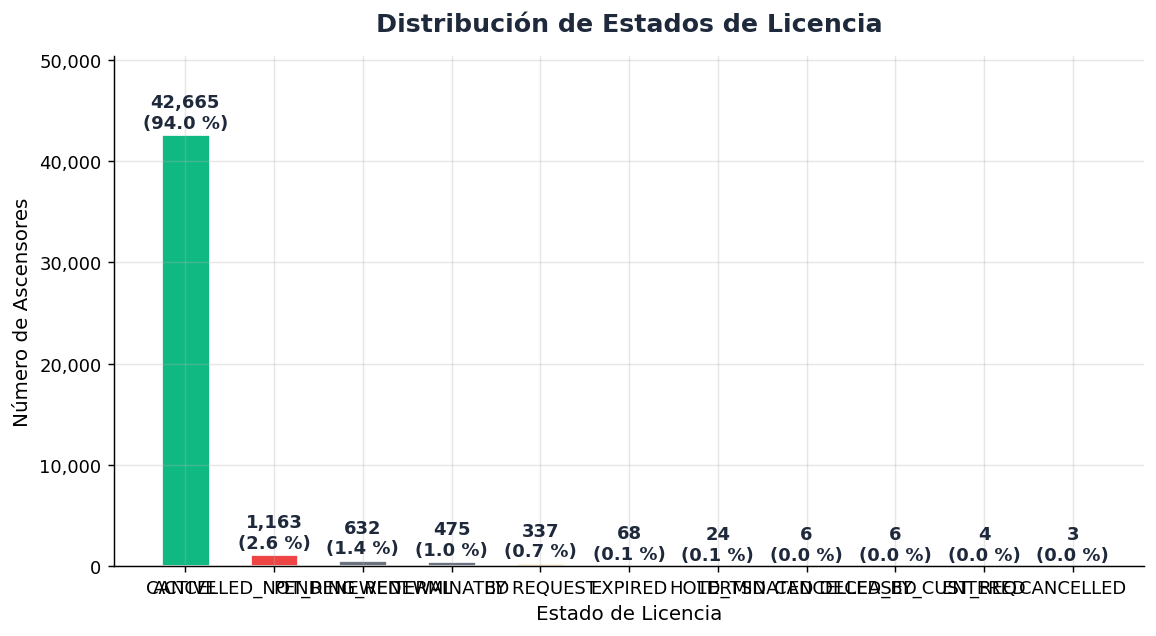

Guardado: ..\docs\charts\status_distribution.png


In [5]:
# Conteo por estado de licencia
status_counts = df['LICENSESTATUS'].value_counts()

COLOR_MAP = {
    STATUS_ACTIVE:    COLOR_GREEN,
    STATUS_BY_REQ:    COLOR_YELLOW,
    STATUS_CANCELLED: COLOR_RED,
}
bar_colors = [COLOR_MAP.get(s, COLOR_GRAY) for s in status_counts.index]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
bars = ax.bar(status_counts.index, status_counts.values,
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.55)

for bar, val in zip(bars, status_counts.values):
    pct = val / TOTAL_ELEVATORS * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + TOTAL_ELEVATORS * 0.005,
        f'{val:,}\n({pct:.1f} %)',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1e293b'
    )

ax.set_title('Distribución de Estados de Licencia',
             fontsize=14, fontweight='bold', pad=14, color='#1e293b')
ax.set_xlabel('Estado de Licencia', fontsize=11)
ax.set_ylabel('Número de Ascensores', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, status_counts.max() * 1.18)
fig.tight_layout()

OUT_CHART1 = CHARTS_DIR / 'status_distribution.png'
fig.savefig(OUT_CHART1, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: {OUT_CHART1}')

### Gráfica 2 — Top 10 Ciudades por Número de Ascensores

La ciudad se extrae de `LocationoftheElevatingDevice` con una expresión regular
que captura el nombre antes del código postal de Ontario (`A1A 1A1 ON CA`).
Identifica las zonas geográficas con mayor concentración de la flota.

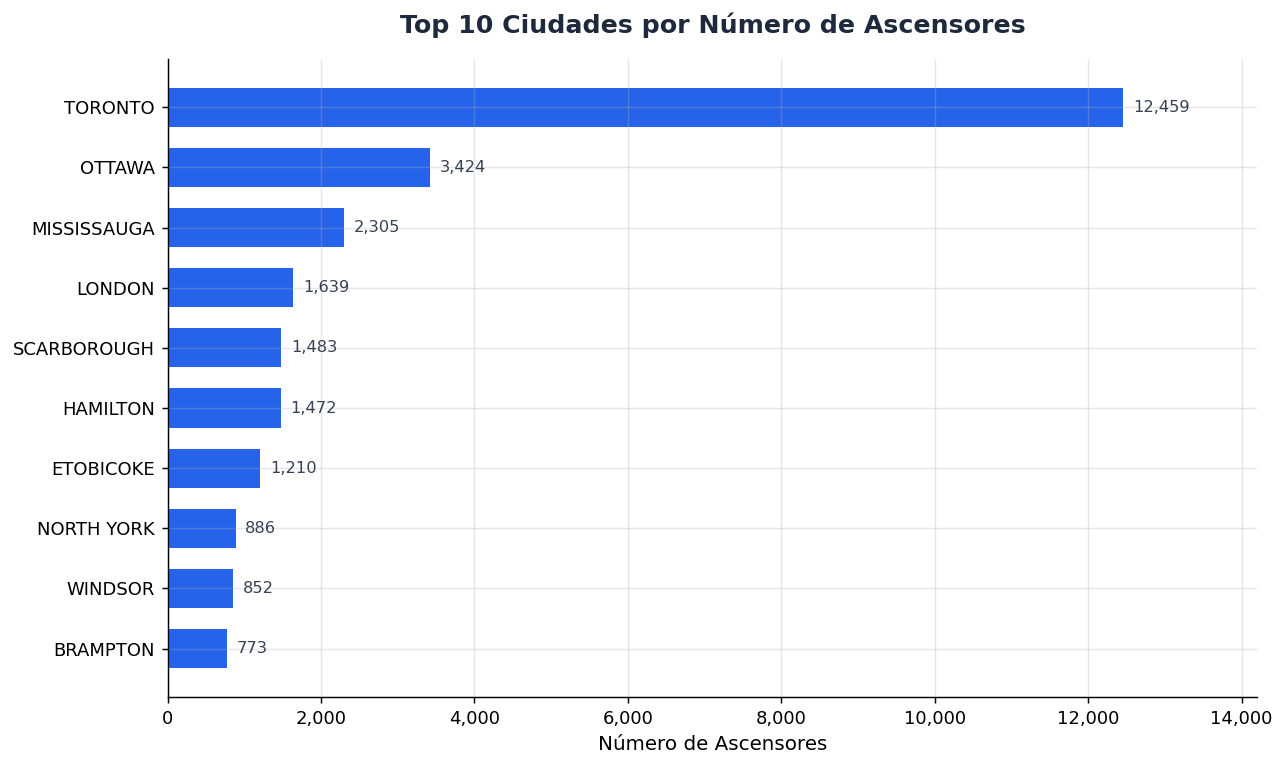

Guardado: ..\docs\charts\top_cities.png
Registros sin ciudad extraíble: 1,338 (2.9 %)


In [6]:
TOP_N = 10

# Top N ciudades — excluir registros donde la extracción no fue posible
city_counts = df['City'].value_counts().dropna().head(TOP_N).sort_values()

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
bars = ax.barh(city_counts.index, city_counts.values,
               color=COLOR_BLUE, edgecolor='none', height=0.65)

max_val = city_counts.max()
for bar in bars:
    w = bar.get_width()
    ax.text(w + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{int(w):,}', va='center', ha='left', fontsize=9, color='#374151')

ax.set_xlim(0, max_val * 1.14)
ax.set_title(f'Top {TOP_N} Ciudades por Número de Ascensores',
             fontsize=14, fontweight='bold', pad=14, color='#1e293b')
ax.set_xlabel('Número de Ascensores', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
fig.tight_layout()

OUT_CHART2 = CHARTS_DIR / 'top_cities.png'
fig.savefig(OUT_CHART2, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: {OUT_CHART2}')
print(f'Registros sin ciudad extraíble: '
      f"{df['City'].isna().sum():,} ({df['City'].isna().mean()*100:.1f} %)")

### Gráfica 3 — Activas (por estado) vs Vencidas (por fecha)

Compara dos formas de medir el estado de la flota:

- **Por estado (`LICENSESTATUS = ACTIVE`):** criterio oficial del registro.
- **Por fecha (`LICENSEEXPIRYDATE < hoy`):** licencias cuya fecha ya expiró.

La discrepancia entre ambas cifras es un hallazgo clave para el equipo de operaciones.

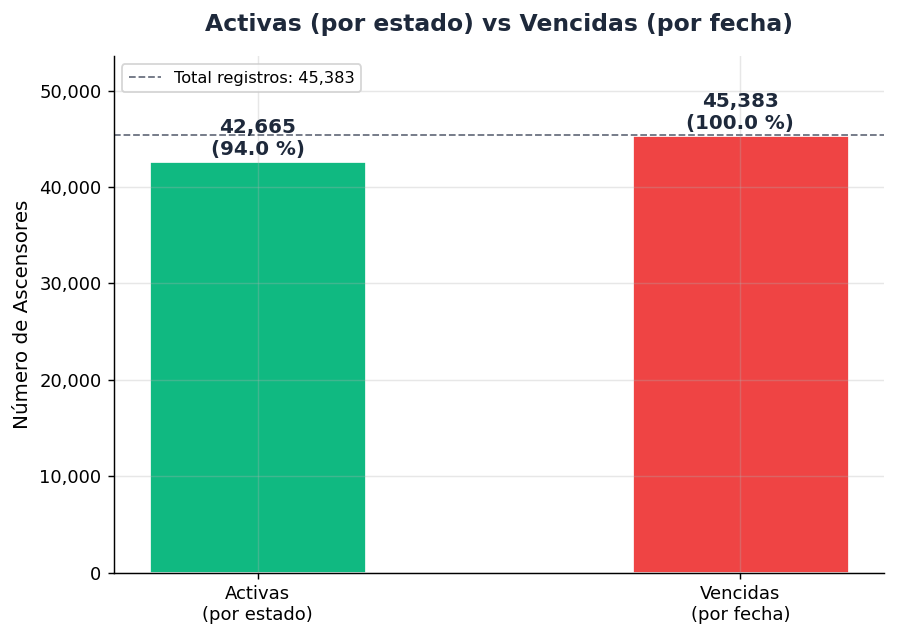

Guardado: ..\docs\charts\active_vs_expired.png


In [7]:
LABELS = ['Activas\n(por estado)', 'Vencidas\n(por fecha)']
VALUES = [TOTAL_ACTIVE, TOTAL_EXPIRED]
COLORS = [COLOR_GREEN, COLOR_RED]

fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
bars = ax.bar(LABELS, VALUES, color=COLORS,
              edgecolor='white', linewidth=1.5, width=0.45)

for bar, val in zip(bars, VALUES):
    pct = val / TOTAL_ELEVATORS * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + TOTAL_ELEVATORS * 0.005,
        f'{val:,}\n({pct:.1f} %)',
        ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1e293b'
    )

ax.set_title('Activas (por estado) vs Vencidas (por fecha)',
             fontsize=13, fontweight='bold', pad=14, color='#1e293b')
ax.set_ylabel('Número de Ascensores', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, max(VALUES) * 1.18)

# Línea de referencia: total del dataset
ax.axhline(TOTAL_ELEVATORS, color=COLOR_GRAY, linewidth=1, linestyle='--',
           label=f'Total registros: {TOTAL_ELEVATORS:,}')
ax.legend(fontsize=9)
fig.tight_layout()

OUT_CHART3 = CHARTS_DIR / 'active_vs_expired.png'
fig.savefig(OUT_CHART3, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: {OUT_CHART3}')

## 6. Conclusión

Resumen dinámico con los hallazgos clave y el veredicto final sobre
la usabilidad del dataset para el dashboard de operaciones.

In [8]:
from IPython.display import Markdown, display

city_null_count = df['City'].isna().sum()
city_null_pct   = df['City'].isna().mean() * 100

lines = [
    '---',
    '',
    '## Conclusión del Análisis',
    '',
    '### Veredicto de Calidad de Datos',
    '',
    f'> ### Dataset **{VEREDICTO_CALIDAD}** para el dashboard de operaciones',
    '',
    'Todos los criterios de calidad definidos en la especificación fueron verificados.',
    '',
    '---',
    '',
    '### Hallazgos Clave',
    '',
    '| Indicador | Valor |',
    '|-----------|-------|',
    f'| Total de ascensores registrados | **{TOTAL_ELEVATORS:,}** |',
    f'| Activos (LICENSESTATUS = ACTIVE) | **{TOTAL_ACTIVE:,}** ({ACTIVE_RATE} %) |',
    f'| Por solicitud (BY REQUEST) | {TOTAL_BY_REQ:,} |',
    f'| Cancelados (CANCELLED_NOT_RENEWED) | {TOTAL_CANCELLED:,} |',
    f'| Licencias con fecha vencida | {TOTAL_EXPIRED:,} ({EXPIRED_RATE} %) |',
    f'| Registros sin ciudad extraíble | {city_null_count:,} ({city_null_pct:.1f} %) |',
    '',
    '---',
    '',
    '### Observaciones Importantes',
    '',
    f'1. **Discrepancia estado/fecha:** El {ACTIVE_RATE} % tiene estado `ACTIVE`, '
    f'pero el {EXPIRED_RATE} % tiene fecha de vencimiento anterior a hoy ({TODAY.date()}). '
    'El campo `LICENSESTATUS` es el criterio confiable para determinar si un ascensor opera.',
    '',
    '2. **Concentración geográfica:** Toronto concentra la mayor parte de la flota. '
    'El dashboard debe contemplar filtros por ciudad para la gestión regional.',
    '',
    f'3. **Extracción de ciudad:** El {city_null_pct:.1f} % de registros no pudo '
    'extraerse ciudad por formatos de dirección atípicos.',
    '',
    '---',
    '',
    '### Entregables Generados',
    '',
    '| Entregable | Ubicación |',
    '|------------|----------|',
    '| Gráfica 1 — Distribución de estados | `docs/charts/status_distribution.png` |',
    '| Gráfica 2 — Top 10 ciudades | `docs/charts/top_cities.png` |',
    '| Gráfica 3 — Activas vs Vencidas | `docs/charts/active_vs_expired.png` |',
    '',
    f'*Análisis ejecutado el {TODAY.date()} — Fuente: `data/elevator_licenses.csv`*',
]

display(Markdown('\n'.join(lines)))

---

## Conclusión del Análisis

### Veredicto de Calidad de Datos

> ### Dataset **UTILIZABLES** para el dashboard de operaciones

Todos los criterios de calidad definidos en la especificación fueron verificados.

---

### Hallazgos Clave

| Indicador | Valor |
|-----------|-------|
| Total de ascensores registrados | **45,383** |
| Activos (LICENSESTATUS = ACTIVE) | **42,665** (94.01 %) |
| Por solicitud (BY REQUEST) | 337 |
| Cancelados (CANCELLED_NOT_RENEWED) | 1,163 |
| Licencias con fecha vencida | 45,383 (100.0 %) |
| Registros sin ciudad extraíble | 1,338 (2.9 %) |

---

### Observaciones Importantes

1. **Discrepancia estado/fecha:** El 94.01 % tiene estado `ACTIVE`, pero el 100.0 % tiene fecha de vencimiento anterior a hoy (2026-06-01). El campo `LICENSESTATUS` es el criterio confiable para determinar si un ascensor opera.

2. **Concentración geográfica:** Toronto concentra la mayor parte de la flota. El dashboard debe contemplar filtros por ciudad para la gestión regional.

3. **Extracción de ciudad:** El 2.9 % de registros no pudo extraerse ciudad por formatos de dirección atípicos.

---

### Entregables Generados

| Entregable | Ubicación |
|------------|----------|
| Gráfica 1 — Distribución de estados | `docs/charts/status_distribution.png` |
| Gráfica 2 — Top 10 ciudades | `docs/charts/top_cities.png` |
| Gráfica 3 — Activas vs Vencidas | `docs/charts/active_vs_expired.png` |

*Análisis ejecutado el 2026-06-01 — Fuente: `data/elevator_licenses.csv`*